# Pendulum Data Preprocessing

Distilled workflow to get corrected data ready for smoothing/analysis.

**Key steps:**
1. Load tracking and field data
2. Preprocess (NaN handling, angle unwrapping)
3. Synchronize and interpolate to 2000 Hz
4. Apply drift correction (time-scaling)

**Output:** `theta_field_trim`, `theta_trk_trim`, `omega_trk_trim`, `alpha_trk_trim`, `mag_field_trim`, `t_trim`

In [1]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import linregress
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Configuration
TRACK_FILE = 'chirp-data/unlube3-1.csv'
FIELD_FILE = 'chirp3-unlube.csv'
B_START = 1529
B_END = 6521
FS_NEW = 2000  # Hz
T_START = 0
T_END = 5
TRIM_END = 6521  # Final length after resampling

## Step 1: Load and Preprocess Tracking Data

In [2]:
# Load tracking data (CSV has 2 header rows)
track_tbl = pd.read_csv(TRACK_FILE, header=1)

t_trk = track_tbl['t'].values
theta_trk = track_tbl['θ'].values / 180 * np.pi  # Convert to radians (already unwrapped)
omega_trk = track_tbl['ω'].values / 180 * np.pi  # Convert to rad/s

# Handle NaN values (backward fill then forward fill)
if np.isnan(omega_trk).sum() > 0:
    omega_series = pd.Series(omega_trk)
    omega_trk = omega_series.bfill().ffill().values

if np.isnan(theta_trk).sum() > 0:
    theta_series = pd.Series(theta_trk)
    theta_trk = theta_series.bfill().ffill().values

print(f"Loaded {len(t_trk)} tracking samples")
print(f"Time range: [{t_trk[0]:.3f}, {t_trk[-1]:.3f}] s")
print(f"Theta range: [{np.min(theta_trk):.2f}, {np.max(theta_trk):.2f}] rad")

Loaded 10070 tracking samples
Time range: [0.000, 5.035] s
Theta range: [-95.44, 121.45] rad


## Step 2: Load and Preprocess Field Data

In [3]:
# Load field data (skip 6 header rows, semicolon-separated)
field_tbl = pd.read_csv(FIELD_FILE, skiprows=6, sep=';')

idx = field_tbl['Index'].values
t_field = idx * 1e-3  # Convert ms to seconds
t_field = t_field[B_START:B_END]  # Trim to relevant window

Bx = field_tbl['Bx[mT]'].values[B_START:B_END]
By = field_tbl['By[mT]'].values[B_START:B_END]
Bz = field_tbl['Bz[mT]'].values[B_START:B_END]

# Compute field angle (wrapped to [-π, π])
theta_field_wrapped = np.arctan2(Bz, By)

# Unwrap field angle to make it continuous (removes discontinuities at ±π)
theta_field = np.unwrap(theta_field_wrapped)

mag_field = np.linalg.norm([By, Bz], axis=0)

print(f"Loaded {len(t_field)} field samples")
print(f"Time range: [{t_field[0]:.3f}, {t_field[-1]:.3f}] s")
print(f"Field angle range: [{np.min(theta_field):.2f}, {np.max(theta_field):.2f}] rad")

Loaded 4992 field samples
Time range: [1.530, 6.521] s
Field angle range: [-95.58, 120.73] rad


## Step 3: Synchronize and Interpolate to 2000 Hz

In [4]:
# Create uniform time grid at 2000 Hz
t_new = np.arange(T_START, T_END + 1/FS_NEW, 1/FS_NEW)

# Offset field time to start at zero
t_field_offset = t_field - t_field[0]

# Interpolate all signals to 2000 Hz using linear interpolation
theta_field_spline = interp1d(t_field_offset, theta_field, kind='linear',
                              bounds_error=False, fill_value='extrapolate')(t_new)
theta_field_wrapped_spline = interp1d(t_field_offset, theta_field_wrapped, kind='linear',
                                      bounds_error=False, fill_value='extrapolate')(t_new)
mag_field_spline = interp1d(t_field_offset, mag_field, kind='linear',
                            bounds_error=False, fill_value='extrapolate')(t_new)
omega_trk_spline = interp1d(t_trk, omega_trk, kind='linear',
                            bounds_error=False, fill_value='extrapolate')(t_new)
theta_trk_spline = interp1d(t_trk, theta_trk, kind='linear',
                            bounds_error=False, fill_value='extrapolate')(t_new)

# Compute angular acceleration
alpha_trk_spline = np.gradient(omega_trk_spline, 1/FS_NEW)

# Trim to specified length
theta_field_trim = theta_field_spline[:TRIM_END]
theta_field_wrapped_trim = theta_field_wrapped_spline[:TRIM_END]
mag_field_trim = mag_field_spline[:TRIM_END]
theta_trk_trim = theta_trk_spline[:TRIM_END]
theta_trk_wrapped_trim = np.arctan2(np.sin(theta_trk_spline[:TRIM_END]), np.cos(theta_trk_spline[:TRIM_END]))
omega_trk_trim = omega_trk_spline[:TRIM_END]
alpha_trk_trim = alpha_trk_spline[:TRIM_END]
t_trim = t_new[:TRIM_END]

print(f"Resampled to {FS_NEW} Hz")
print(f"Final length: {len(t_trim)} samples ({len(t_trim)/FS_NEW:.3f} seconds)")
print(f"Time range: [0, {t_trim[-1]:.4f}] s")

Resampled to 2000 Hz
Final length: 6521 samples (3.260 seconds)
Time range: [0, 3.2600] s


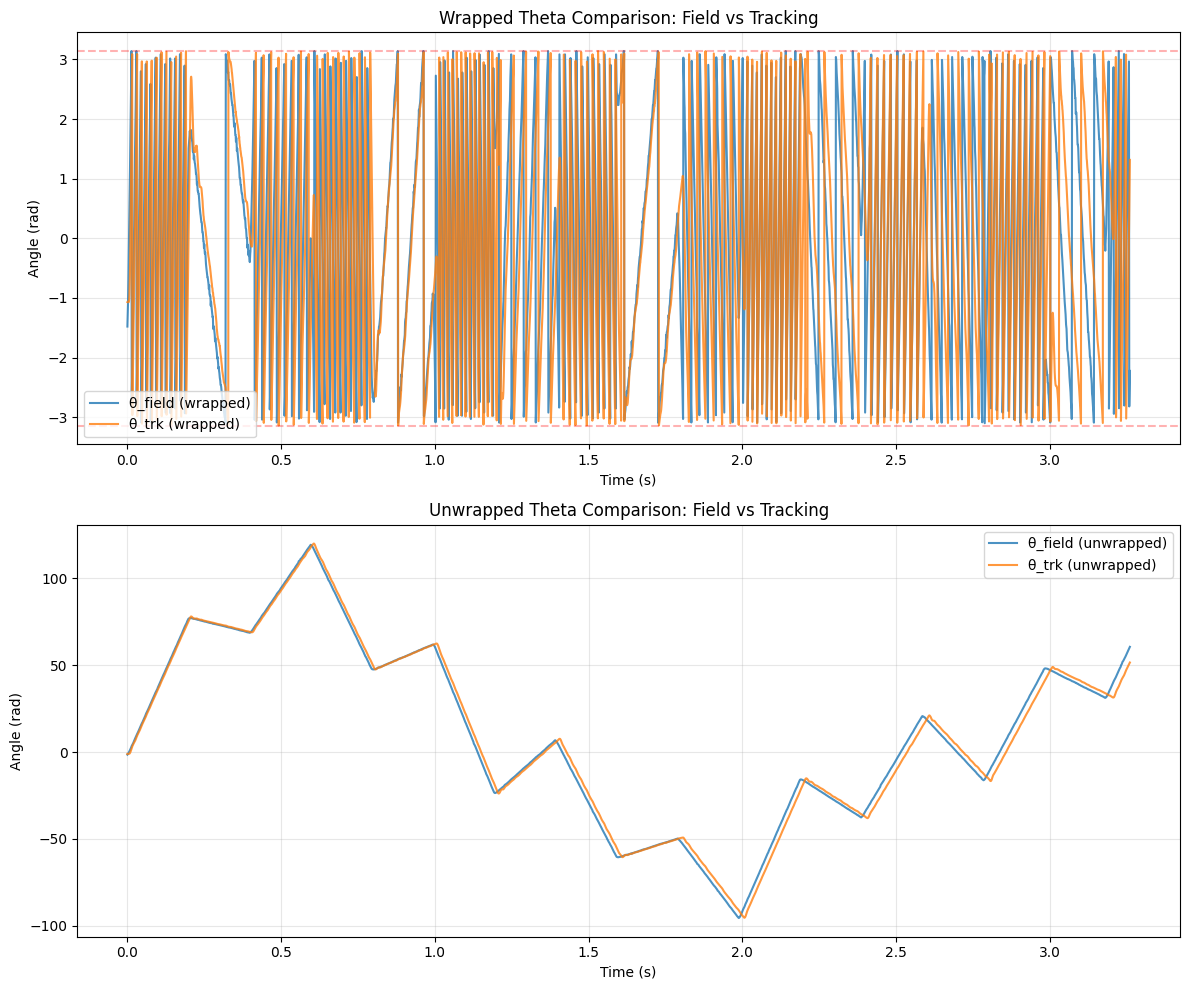

In [5]:
# Plot overlay of wrapped and unwrapped theta values
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top plot: Wrapped versions
axes[0].plot(t_trim, theta_field_wrapped_trim, label='θ_field (wrapped)', linewidth=1.5, alpha=0.8)
axes[0].plot(t_trim, theta_trk_wrapped_trim, label='θ_trk (wrapped)', linewidth=1.5, alpha=0.8)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Angle (rad)')
axes[0].set_title('Wrapped Theta Comparison: Field vs Tracking')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=np.pi, color='r', linestyle='--', alpha=0.3, label='±π')
axes[0].axhline(y=-np.pi, color='r', linestyle='--', alpha=0.3)

# Bottom plot: Unwrapped versions
axes[1].plot(t_trim, theta_field_trim, label='θ_field (unwrapped)', linewidth=1.5, alpha=0.8)
axes[1].plot(t_trim, theta_trk_trim, label='θ_trk (unwrapped)', linewidth=1.5, alpha=0.8)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Angle (rad)')
axes[1].set_title('Unwrapped Theta Comparison: Field vs Tracking')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Analyze RELATIVE clock drift between the two data sources
# Note: Internal drift checks don't make sense because:
# - Tracking timestamps use its own clock (will always appear uniform to itself)
# - Field timestamps are synthetic (computed from index, uniform by construction)
# So we need to compare the clocks RELATIVE to each other via phase difference

print("="*70)
print("RELATIVE CLOCK DRIFT ANALYSIS")
print("="*70)
print("\nNote: Internal drift checks are meaningless because:")
print("  - Tracking: Uses its own clock for timestamps (always uniform to itself)")
print("  - Field: Synthetic time from index (uniform by construction)")
print("  → Need to compare clocks RELATIVE to each other\n")

# After synchronization, compute phase difference
phase_diff = theta_field_trim - theta_trk_trim

# Fit linear trend to phase difference (growing phase = clock rate mismatch)
slope_phase, intercept_phase, r_phase, p_phase, _ = linregress(t_trim, phase_diff)

print("1. PHASE DIFFERENCE ANALYSIS (after synchronization)")
print("-" * 70)
print(f"  Phase difference slope: {slope_phase:.6f} rad/s")
print(f"  Phase difference intercept: {intercept_phase:.4f} rad")
print(f"  R²: {r_phase**2:.4f}")
print(f"  Total phase drift over {t_trim[-1]:.3f}s: {slope_phase * t_trim[-1]:.4f} rad ({slope_phase * t_trim[-1] * 180/np.pi:.2f}°)")

# Estimate clock rate mismatch from phase drift
# If phase_diff = slope * t, then one clock is running faster by: slope / omega_avg
omega_avg = np.mean(np.abs(omega_trk_trim))
clock_rate_error = slope_phase / omega_avg if omega_avg > 0 else 0

print(f"\n2. ESTIMATED CLOCK RATE MISMATCH")
print("-" * 70)
print(f"  Average angular velocity: {omega_avg:.2f} rad/s")
print(f"  Estimated clock rate error: {clock_rate_error*100:.4f}%")
print(f"  Clock rate factor: {1 + clock_rate_error:.8f}")

if abs(clock_rate_error) > 0.0001:
    print(f"\n  ⚠ CLOCK RATE MISMATCH DETECTED")
    print(f"     One clock is running {abs(clock_rate_error)*100:.4f}% {'faster' if clock_rate_error > 0 else 'slower'}")
    print(f"     This causes phase to drift by {slope_phase:.6f} rad/s")
    print(f"     Over {t_trim[-1]:.3f}s, this accumulates to {slope_phase * t_trim[-1]:.4f} rad")
else:
    print(f"\n  ✓ Clock rates appear well-matched (error < 0.01%)")

# Check if phase difference is growing linearly (indicates rate mismatch)
if abs(slope_phase) > 0.01:
    print(f"\n3. RECOMMENDATION")
    print("-" * 70)
    print(f"  Apply time-scaling correction:")
    print(f"    - Scale one clock by factor: {1 - clock_rate_error:.8f}")
    print(f"    - This should remove the linear phase drift")

RELATIVE CLOCK DRIFT ANALYSIS

Note: Internal drift checks are meaningless because:
  - Tracking: Uses its own clock for timestamps (always uniform to itself)
  - Field: Synthetic time from index (uniform by construction)
  → Need to compare clocks RELATIVE to each other

1. PHASE DIFFERENCE ANALYSIS (after synchronization)
----------------------------------------------------------------------
  Phase difference slope: 1.030183 rad/s
  Phase difference intercept: -1.6446 rad
  R²: 0.0612
  Total phase drift over 3.260s: 3.3584 rad (192.42°)

2. ESTIMATED CLOCK RATE MISMATCH
----------------------------------------------------------------------
  Average angular velocity: 237.75 rad/s
  Estimated clock rate error: 0.4333%
  Clock rate factor: 1.00433305

  ⚠ CLOCK RATE MISMATCH DETECTED
     One clock is running 0.4333% faster
     This causes phase to drift by 1.030183 rad/s
     Over 3.260s, this accumulates to 3.3584 rad

3. RECOMMENDATION
--------------------------------------------

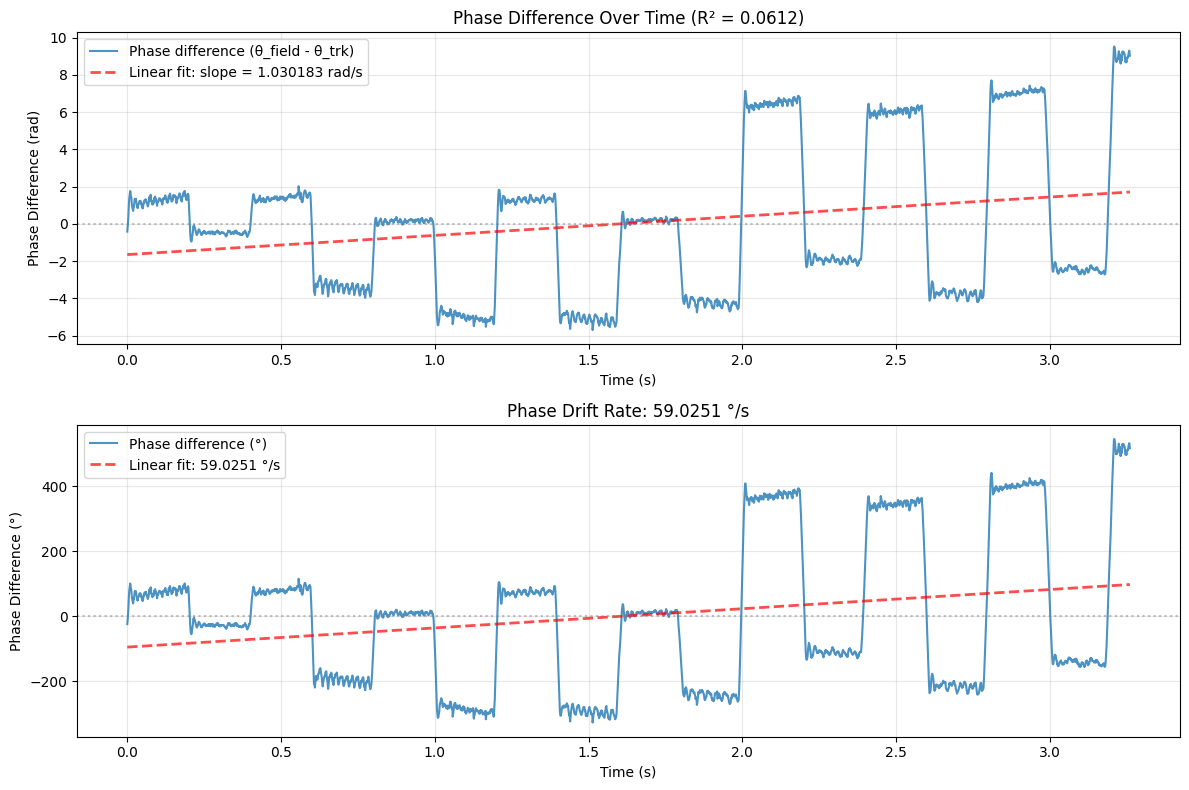

In [7]:
# Visualize phase difference and clock drift
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top plot: Phase difference over time
axes[0].plot(t_trim, phase_diff, linewidth=1.5, alpha=0.8, label='Phase difference (θ_field - θ_trk)')
if abs(slope_phase) > 0.001:
    # Fit line
    fit_line = intercept_phase + slope_phase * t_trim
    axes[0].plot(t_trim, fit_line, 'r--', linewidth=2, alpha=0.7, 
                label=f'Linear fit: slope = {slope_phase:.6f} rad/s')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Phase Difference (rad)')
axes[0].set_title(f'Phase Difference Over Time (R² = {r_phase**2:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='gray', linestyle=':', alpha=0.5)

# Bottom plot: Phase difference in degrees
phase_diff_deg = phase_diff * 180 / np.pi
fit_line_deg = (intercept_phase + slope_phase * t_trim) * 180 / np.pi
axes[1].plot(t_trim, phase_diff_deg, linewidth=1.5, alpha=0.8, label='Phase difference (°)')
if abs(slope_phase) > 0.001:
    axes[1].plot(t_trim, fit_line_deg, 'r--', linewidth=2, alpha=0.7,
                label=f'Linear fit: {slope_phase*180/np.pi:.4f} °/s')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Phase Difference (°)')
axes[1].set_title(f'Phase Drift Rate: {slope_phase*180/np.pi:.4f} °/s')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## Analyze Phase Difference Normalized by Field Omega

Since phase difference should correlate with omega, analyze phase_diff / omega_field for drift.

In [8]:
# Compute omega_field from theta_field
omega_field_trim = np.gradient(theta_field_trim, t_trim)

# Compute phase difference normalized by omega_field
# This should be more stable if phase difference correlates with omega
# Avoid division by zero by masking out small omega values
omega_threshold = 1e-3  # rad/s - minimum omega to avoid division issues
valid_mask = np.abs(omega_field_trim) > omega_threshold

phase_diff_normalized = np.zeros_like(phase_diff)
phase_diff_normalized[valid_mask] = phase_diff[valid_mask] / omega_field_trim[valid_mask]
phase_diff_normalized[~valid_mask] = np.nan

# Smooth the normalized phase difference to reduce outliers
from scipy.ndimage import gaussian_filter1d
sigma_smooth_norm = 5.0  # Gaussian smoothing sigma (in samples)
phase_diff_normalized_smooth = phase_diff_normalized.copy()
phase_diff_normalized_smooth[valid_mask] = gaussian_filter1d(
    phase_diff_normalized[valid_mask], sigma=sigma_smooth_norm)

# Fit linear trend to smoothed normalized phase difference to detect drift
valid_indices = np.where(valid_mask)[0]
if len(valid_indices) > 0:
    slope_norm, intercept_norm, r_norm, p_norm, _ = linregress(
        t_trim[valid_indices], phase_diff_normalized_smooth[valid_indices])
    # Also fit to raw for comparison
    slope_norm_raw, intercept_norm_raw, r_norm_raw, _, _ = linregress(
        t_trim[valid_indices], phase_diff_normalized[valid_indices])
else:
    slope_norm = intercept_norm = r_norm = p_norm = np.nan
    slope_norm_raw = intercept_norm_raw = r_norm_raw = np.nan

print("="*70)
print("PHASE DIFFERENCE NORMALIZED BY FIELD OMEGA")
print("="*70)
print(f"\nComputed: phase_diff / omega_field")
print(f"  Valid points (|omega_field| > {omega_threshold}): {np.sum(valid_mask)} / {len(t_trim)} ({np.sum(valid_mask)/len(t_trim)*100:.2f}%)")
print(f"  Invalid points (near zero omega): {np.sum(~valid_mask)} ({np.sum(~valid_mask)/len(t_trim)*100:.2f}%)")

if len(valid_indices) > 0:
    print(f"\nNormalized phase difference statistics:")
    print(f"  Mean: {np.nanmean(phase_diff_normalized):.6f}")
    print(f"  Std: {np.nanstd(phase_diff_normalized):.6f}")
    print(f"  Min: {np.nanmin(phase_diff_normalized):.6f}")
    print(f"  Max: {np.nanmax(phase_diff_normalized):.6f}")
    
    print(f"\nDrift analysis (linear fit to smoothed normalized phase difference):")
    print(f"  Smoothing: Gaussian filter, σ = {sigma_smooth_norm} samples")
    print(f"  Slope (smoothed): {slope_norm:.6f} s⁻¹")
    print(f"  Intercept (smoothed): {intercept_norm:.6f}")
    print(f"  R² (smoothed): {r_norm**2:.4f}")
    print(f"  Total drift over {t_trim[-1]:.3f}s: {slope_norm * t_trim[-1]:.6f}")
    
    if len(valid_indices) > 0 and not np.isnan(slope_norm_raw):
        print(f"\n  Comparison (raw, no smoothing):")
        print(f"    Slope (raw): {slope_norm_raw:.6f} s⁻¹")
        print(f"    R² (raw): {r_norm_raw**2:.4f}")
    
    if abs(slope_norm) > 0.001:
        print(f"\n  ⚠ DRIFT DETECTED in normalized phase difference")
        print(f"     Slope = {slope_norm:.6f} s⁻¹ indicates systematic drift")
    else:
        print(f"\n  ✓ No significant drift detected in normalized phase difference")
else:
    print("\n  ⚠ No valid points for analysis (omega_field too small)")

PHASE DIFFERENCE NORMALIZED BY FIELD OMEGA

Computed: phase_diff / omega_field
  Valid points (|omega_field| > 0.001): 6441 / 6521 (98.77%)
  Invalid points (near zero omega): 80 (1.23%)

Normalized phase difference statistics:
  Mean: 0.013240
  Std: 0.041961
  Min: -0.973287
  Max: 2.017328

Drift analysis (linear fit to smoothed normalized phase difference):
  Smoothing: Gaussian filter, σ = 5.0 samples
  Slope (smoothed): 0.006072 s⁻¹
  Intercept (smoothed): 0.003317
  R² (smoothed): 0.2332
  Total drift over 3.260s: 0.019796

  Comparison (raw, no smoothing):
    Slope (raw): 0.006072 s⁻¹
    R² (raw): 0.0185

  ⚠ DRIFT DETECTED in normalized phase difference
     Slope = 0.006072 s⁻¹ indicates systematic drift


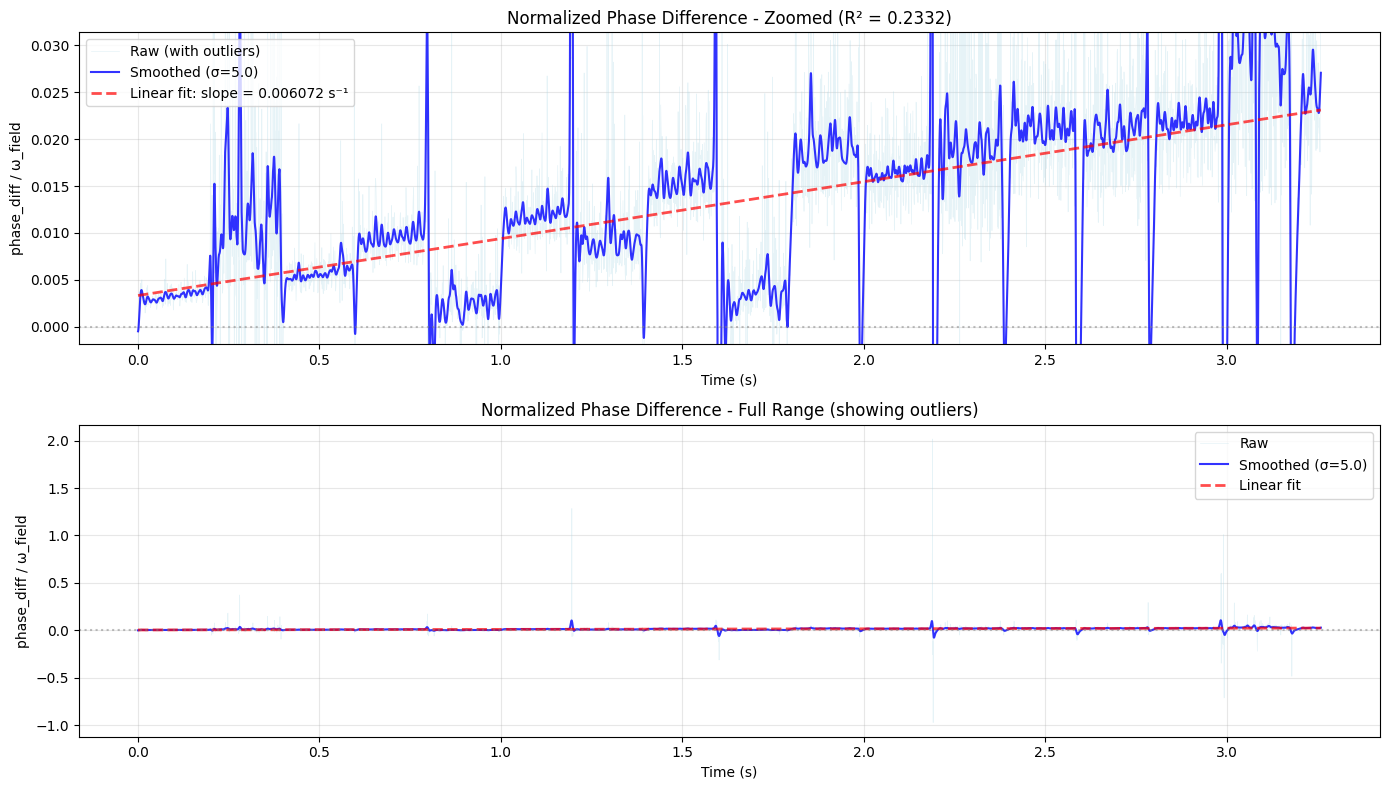

In [9]:
# Visualize normalized phase difference and drift
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top plot: Phase difference normalized by omega_field (zoomed in, smoothed)
axes[0].plot(t_trim[valid_mask], phase_diff_normalized[valid_mask], linewidth=0.5, alpha=0.3, 
            label='Raw (with outliers)', color='lightblue')
axes[0].plot(t_trim[valid_mask], phase_diff_normalized_smooth[valid_mask], linewidth=1.5, alpha=0.8, 
            label=f'Smoothed (σ={sigma_smooth_norm})', color='blue')
if len(valid_indices) > 0 and not np.isnan(slope_norm):
    fit_line_norm = intercept_norm + slope_norm * t_trim[valid_indices]
    axes[0].plot(t_trim[valid_indices], fit_line_norm, 'r--', linewidth=2, alpha=0.7, 
                label=f'Linear fit: slope = {slope_norm:.6f} s⁻¹')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('phase_diff / ω_field')
axes[0].set_title(f'Normalized Phase Difference - Zoomed (R² = {r_norm**2:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='gray', linestyle=':', alpha=0.5)

# Zoom in: use percentiles to exclude extreme outliers
if len(valid_indices) > 0:
    y_values = phase_diff_normalized_smooth[valid_indices]
    y_p5 = np.nanpercentile(y_values, 5)
    y_p95 = np.nanpercentile(y_values, 95)
    y_range = y_p95 - y_p5
    y_margin = y_range * 0.1  # 10% margin
    axes[0].set_ylim(y_p5 - y_margin, y_p95 + y_margin)

# Bottom plot: Full range view (to see outliers)
axes[1].plot(t_trim[valid_mask], phase_diff_normalized[valid_mask], linewidth=0.5, alpha=0.3, 
            label='Raw', color='lightblue')
axes[1].plot(t_trim[valid_mask], phase_diff_normalized_smooth[valid_mask], linewidth=1.5, alpha=0.8, 
            label=f'Smoothed (σ={sigma_smooth_norm})', color='blue')
if len(valid_indices) > 0 and not np.isnan(slope_norm):
    fit_line_norm = intercept_norm + slope_norm * t_trim[valid_indices]
    axes[1].plot(t_trim[valid_indices], fit_line_norm, 'r--', linewidth=2, alpha=0.7, 
                label=f'Linear fit')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('phase_diff / ω_field')
axes[1].set_title('Normalized Phase Difference - Full Range (showing outliers)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [10]:
# Step-by-step drift analysis
print("\n" + "="*70)
print("DRIFT ANALYSIS - STEP BY STEP")
print("="*70)

# Step 1: Naive absolute drift
print(f"\n1. NAIVE ABSOLUTE DRIFT:")
print(f"   Phase difference slope: {slope_phase:.6f} rad/s")
print(f"   R²: {r_phase**2:.4f}")
print(f"   Clock rate error: {clock_rate_error*100:.6f}%")
correction_factor_naive = 1 - clock_rate_error
print(f"   Correction factor: {correction_factor_naive:.8f}")

# Step 2: Normalized phase drift
if len(valid_indices) > 0 and not np.isnan(slope_norm):
    print(f"\n2. NORMALIZED PHASE DRIFT:")
    print(f"   Normalized ratio slope: {slope_norm:.6f} s⁻¹")
    print(f"   R²: {r_norm**2:.4f}")
    print(f"   Interpretation: phase_diff/omega_field changes by {slope_norm:.6f} per second")
    
    # Step 3: Omega drift fit
    mean_omega = np.mean(omega_field_trim[valid_indices])
    
    # Fit linear trend directly to omega_field (naive approach)
    slope_omega_naive, intercept_omega_naive, r_omega_naive, _, _ = linregress(
        t_trim[valid_indices], omega_field_trim[valid_indices])
    slope_omega_norm_naive = slope_omega_naive / mean_omega if abs(mean_omega) > 1e-3 else np.nan
    
    print(f"\n3. OMEGA DRIFT FIT:")
    print(f"   Mean omega_field: {mean_omega:.4f} rad/s")
    print(f"   Omega_field linear fit slope: {slope_omega_naive:.6f} rad/s per second")
    print(f"   Normalized omega drift: {slope_omega_norm_naive:.6f} s⁻¹")
    print(f"   R²: {r_omega_naive**2:.4f}")
    
    print(f"\n" + "-"*70)
    print(f"Summary:")
    print(f"  Absolute phase drift: {slope_phase:.6f} rad/s")
    print(f"  Normalized phase drift: {slope_norm:.6f} s⁻¹")
    print(f"  Normalized omega drift: {slope_omega_norm_naive:.6f} s⁻¹")
else:
    print("\n⚠ Cannot compute normalized drift - insufficient valid data")


DRIFT ANALYSIS - STEP BY STEP

1. NAIVE ABSOLUTE DRIFT:
   Phase difference slope: 1.030183 rad/s
   R²: 0.0612
   Clock rate error: 0.433305%
   Correction factor: 0.99566695

2. NORMALIZED PHASE DRIFT:
   Normalized ratio slope: 0.006072 s⁻¹
   R²: 0.2332
   Interpretation: phase_diff/omega_field changes by 0.006072 per second

3. OMEGA DRIFT FIT:
   Mean omega_field: 19.3136 rad/s
   Omega_field linear fit slope: 20.905633 rad/s per second
   Normalized omega drift: 1.082431 s⁻¹
   R²: 0.0050

----------------------------------------------------------------------
Summary:
  Absolute phase drift: 1.030183 rad/s
  Normalized phase drift: 0.006072 s⁻¹
  Normalized omega drift: 1.082431 s⁻¹


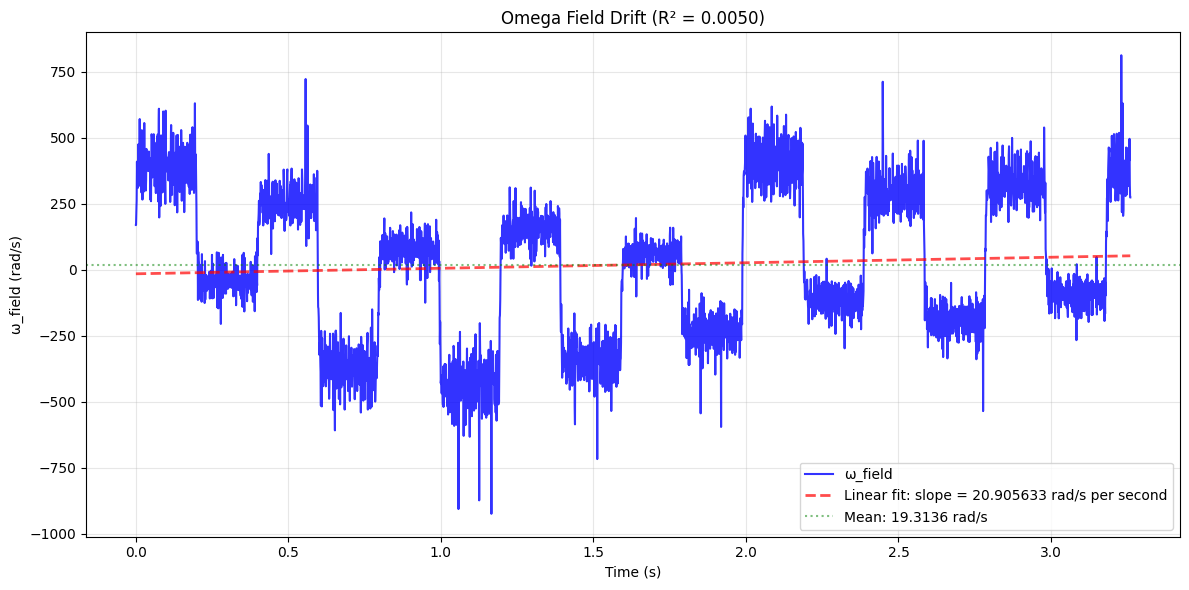

In [11]:
# Plot omega drift
if len(valid_indices) > 0 and not np.isnan(slope_omega_naive):
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    # Plot omega_field over time with linear fit
    fit_line_omega = intercept_omega_naive + slope_omega_naive * t_trim[valid_indices]
    ax.plot(t_trim[valid_indices], omega_field_trim[valid_indices], linewidth=1.5, alpha=0.8, 
            label='ω_field', color='blue')
    ax.plot(t_trim[valid_indices], fit_line_omega, 'r--', linewidth=2, alpha=0.7, 
            label=f'Linear fit: slope = {slope_omega_naive:.6f} rad/s per second')
    ax.axhline(y=mean_omega, color='green', linestyle=':', alpha=0.5, 
               label=f'Mean: {mean_omega:.4f} rad/s')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('ω_field (rad/s)')
    ax.set_title(f'Omega Field Drift (R² = {r_omega_naive**2:.4f})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Cannot plot omega drift - insufficient valid data")

In [12]:
from scipy.optimize import minimize_scalar

# Objective function: minimize absolute slope of normalized phase difference
# Decision variable: time scaling factor (clock rate correction)
# We'll scale the field time axis: t_field_scaled = t_trim * scale_factor
# Both signals start at t=0, but one clock runs faster/slower

def objective_slope(scale_factor):
    """
    Compute absolute slope of normalized phase difference after applying time scaling.
    
    Args:
        scale_factor: Time scaling factor (1.0 = no scaling, >1.0 = field clock faster)
    
    Returns:
        Absolute value of slope of normalized phase difference
    """
    # Apply time scaling to field data
    # Scale the time axis: if scale_factor > 1, field clock runs faster (time compressed)
    t_field_scaled = t_trim * scale_factor
    
    # Interpolate theta_field at scaled time points
    theta_field_interp = interp1d(t_trim, theta_field_trim, kind='linear',
                                   bounds_error=False, fill_value='extrapolate')
    theta_field_scaled = theta_field_interp(t_field_scaled)
    
    # Compute omega_field from scaled theta_field
    # Need to account for scaling in the derivative
    dt = t_trim[1] - t_trim[0]  # Original time step
    dt_scaled = dt * scale_factor  # Scaled time step
    omega_field_scaled = np.gradient(theta_field_scaled, dt_scaled)
    
    # Compute phase difference (both on same time grid t_trim)
    phase_diff_scaled = theta_field_scaled - theta_trk_trim
    
    # Normalize by omega_field (avoid division by zero)
    omega_threshold = 0.1  # Same threshold as before
    valid_mask = np.abs(omega_field_scaled) > omega_threshold
    
    if np.sum(valid_mask) < 10:  # Need enough points
        return 1e6  # Large penalty
    
    # Compute normalized phase difference
    phase_diff_normalized_scaled = np.full_like(phase_diff_scaled, np.nan)
    phase_diff_normalized_scaled[valid_mask] = (
        phase_diff_scaled[valid_mask] / omega_field_scaled[valid_mask]
    )
    
    # Fit line to normalized phase difference
    valid_indices = np.where(valid_mask)[0]
    if len(valid_indices) < 10:
        return 1e6
    
    # Optional: smooth before fitting (same as before)
    phase_diff_normalized_smooth = phase_diff_normalized_scaled.copy()
    phase_diff_normalized_smooth[valid_mask] = gaussian_filter1d(
        phase_diff_normalized_scaled[valid_mask], sigma=5.0)
    
    # Fit line
    slope, _, _, _, _ = linregress(
        t_trim[valid_indices], phase_diff_normalized_smooth[valid_indices])
    
    # Return absolute slope (we want this to be zero)
    return abs(slope)

# Search for optimal scaling factor
# Scale range: try scaling field clock by ±1% (±0.01 from 1.0)
# scale_factor > 1 means field clock runs faster (need to slow it down)
scale_range = (0.99, 1.01)  # ±1% clock rate correction

print("="*70)
print("OPTIMIZING TIME SCALING FOR ZERO NORMALIZED PHASE DIFFERENCE SLOPE")
print("="*70)
print(f"\nSearch range: [{scale_range[0]:.4f}, {scale_range[1]:.4f}]")
print(f"              Clock rate correction: ±{abs(scale_range[0]-1.0)*100:.1f}%")
print(f"\nOptimizing...")

# Optimize using golden section search (good for 1D unimodal functions)
result = minimize_scalar(objective_slope, bounds=scale_range, 
                         method='bounded', options={'xatol': 1e-6})

scale_opt = result.x
slope_opt = result.fun

print(f"\n✓ Optimization complete!")
print(f"  Optimal scale factor: {scale_opt:.8f}")
print(f"  Clock rate correction: {(scale_opt - 1.0)*100:.4f}%")
print(f"  Optimal slope: {slope_opt:.8f} s⁻¹")
print(f"  Function evaluations: {result.nfev}")

# Compute normalized phase difference with optimal scaling
t_field_opt = t_trim * scale_opt
theta_field_interp_opt = interp1d(t_trim, theta_field_trim, kind='linear',
                                   bounds_error=False, fill_value='extrapolate')
theta_field_opt = theta_field_interp_opt(t_field_opt)
dt_opt = (t_trim[1] - t_trim[0]) * scale_opt
omega_field_opt = np.gradient(theta_field_opt, dt_opt)
phase_diff_opt = theta_field_opt - theta_trk_trim

valid_mask_opt = np.abs(omega_field_opt) > 0.1
phase_diff_normalized_opt = np.full_like(phase_diff_opt, np.nan)
phase_diff_normalized_opt[valid_mask_opt] = (
    phase_diff_opt[valid_mask_opt] / omega_field_opt[valid_mask_opt]
)

# Smooth and fit
phase_diff_normalized_opt_smooth = phase_diff_normalized_opt.copy()
phase_diff_normalized_opt_smooth[valid_mask_opt] = gaussian_filter1d(
    phase_diff_normalized_opt[valid_mask_opt], sigma=5.0)

valid_indices_opt = np.where(valid_mask_opt)[0]
slope_opt_final, intercept_opt_final, r_opt_final, _, _ = linregress(
    t_trim[valid_indices_opt], phase_diff_normalized_opt_smooth[valid_indices_opt])

print(f"\nFinal normalized phase difference statistics (with optimal scaling):")
print(f"  Slope: {slope_opt_final:.8f} s⁻¹")
print(f"  Intercept: {intercept_opt_final:.6f}")
print(f"  R²: {r_opt_final**2:.6f}")
print(f"  Improvement: {abs(slope_norm):.8f} → {abs(slope_opt_final):.8f} s⁻¹")
print(f"  Reduction: {(1 - abs(slope_opt_final)/abs(slope_norm))*100:.2f}%")

OPTIMIZING TIME SCALING FOR ZERO NORMALIZED PHASE DIFFERENCE SLOPE

Search range: [0.9900, 1.0100]
              Clock rate correction: ±1.0%

Optimizing...

✓ Optimization complete!
  Optimal scale factor: 0.99351315
  Clock rate correction: -0.6487%
  Optimal slope: 0.00000175 s⁻¹
  Function evaluations: 17

Final normalized phase difference statistics (with optimal scaling):
  Slope: 0.00000175 s⁻¹
  Intercept: 0.002915
  R²: 0.000000
  Improvement: 0.00607233 → 0.00000175 s⁻¹
  Reduction: 99.97%


In [13]:
# Visualize before/after optimization with Plotly (overlaid for easy comparison)
fig = go.Figure()

# Before optimization (original) - data
fig.add_trace(go.Scatter(
    x=t_trim[valid_mask], 
    y=phase_diff_normalized_smooth[valid_mask],
    mode='lines',
    name=f'Before: slope = {slope_norm:.6f} s⁻¹',
    line=dict(color='blue', width=2),
    opacity=0.7
))

# Before optimization - fit line
if len(valid_indices) > 0 and not np.isnan(slope_norm):
    fit_line_orig = intercept_norm + slope_norm * t_trim[valid_indices]
    fig.add_trace(go.Scatter(
        x=t_trim[valid_indices],
        y=fit_line_orig,
        mode='lines',
        name=f'Before fit: slope = {slope_norm:.6f} s⁻¹',
        line=dict(color='blue', width=2, dash='dash'),
        opacity=0.7
    ))

# After optimization - data
fig.add_trace(go.Scatter(
    x=t_trim[valid_mask_opt],
    y=phase_diff_normalized_opt_smooth[valid_mask_opt],
    mode='lines',
    name=f'After: slope = {slope_opt_final:.8f} s⁻¹ (scale = {scale_opt:.6f})',
    line=dict(color='green', width=2),
    opacity=0.8
))

# After optimization - fit line
if len(valid_indices_opt) > 0:
    fit_line_opt = intercept_opt_final + slope_opt_final * t_trim[valid_indices_opt]
    fig.add_trace(go.Scatter(
        x=t_trim[valid_indices_opt],
        y=fit_line_opt,
        mode='lines',
        name=f'After fit: slope = {slope_opt_final:.8f} s⁻¹',
        line=dict(color='green', width=2, dash='dash'),
        opacity=0.8
    ))

# Zero reference line
fig.add_hline(y=0, line_dash="dot", line_color="gray", opacity=0.5, 
              annotation_text="Zero", annotation_position="right")

fig.update_layout(
    title='Normalized Phase Difference: Before vs After Optimization (Overlaid)',
    xaxis_title='Time (s)',
    yaxis_title='phase_diff / ω_field',
    hovermode='closest',
    width=1400,
    height=700,
    legend=dict(x=0.02, y=0.98)
)

fig.show()

print("\n" + "="*70)
print("OPTIMIZATION SUMMARY")
print("="*70)
print(f"Optimal scale factor: {scale_opt:.8f}")
print(f"Clock rate correction: {(scale_opt - 1.0)*100:.4f}%")
print(f"Slope reduction: {abs(slope_norm):.8f} → {abs(slope_opt_final):.8f} s⁻¹")
print(f"Improvement: {(1 - abs(slope_opt_final)/abs(slope_norm))*100:.2f}%")
print("="*70)


OPTIMIZATION SUMMARY
Optimal scale factor: 0.99351315
Clock rate correction: -0.6487%
Slope reduction: 0.00607233 → 0.00000175 s⁻¹
Improvement: 99.97%


## Plot Theta Comparison with Optimal Scaling

Compare theta_trk vs scaled theta_field (both wrapped and unwrapped) using the optimal scaling factor.

In [14]:
# Plot theta_trk vs scaled theta_field using Plotly
# Both wrapped and unwrapped versions

# Compute wrapped versions
theta_trk_wrapped = np.arctan2(np.sin(theta_trk_trim), np.cos(theta_trk_trim))
theta_field_opt_wrapped = np.arctan2(np.sin(theta_field_opt), np.cos(theta_field_opt))

# Plot 1: Unwrapped theta comparison
fig_unwrapped = go.Figure()
fig_unwrapped.add_trace(go.Scatter(
    x=t_trim, 
    y=theta_trk_trim, 
    mode='lines',
    name='θ_trk (unwrapped)',
    line=dict(color='blue', width=2)
))
fig_unwrapped.add_trace(go.Scatter(
    x=t_trim, 
    y=theta_field_opt, 
    mode='lines',
    name=f'θ_field (scaled, unwrapped, scale={scale_opt:.6f})',
    line=dict(color='orange', width=2)
))
fig_unwrapped.update_layout(
    title=f'Unwrapped Theta Comparison (with optimal scaling: {scale_opt:.6f})',
    xaxis_title='Time (s)',
    yaxis_title='Angle (rad)',
    hovermode='closest',
    width=1400,
    height=600,
    legend=dict(x=0.02, y=0.98)
)
fig_unwrapped.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5)
fig_unwrapped.show()

# Plot 2: Wrapped theta comparison
fig_wrapped = go.Figure()
fig_wrapped.add_trace(go.Scatter(
    x=t_trim, 
    y=theta_trk_wrapped, 
    mode='lines',
    name='θ_trk (wrapped)',
    line=dict(color='blue', width=2)
))
fig_wrapped.add_trace(go.Scatter(
    x=t_trim, 
    y=theta_field_opt_wrapped, 
    mode='lines',
    name=f'θ_field (scaled, wrapped, scale={scale_opt:.6f})',
    line=dict(color='orange', width=2)
))
fig_wrapped.update_layout(
    title=f'Wrapped Theta Comparison (with optimal scaling: {scale_opt:.6f})',
    xaxis_title='Time (s)',
    yaxis_title='Angle (rad)',
    hovermode='closest',
    width=1400,
    height=600,
    legend=dict(x=0.02, y=0.98)
)
fig_wrapped.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5)
fig_wrapped.add_hline(y=np.pi, line_dash="dash", line_color="red", opacity=0.3)
fig_wrapped.add_hline(y=-np.pi, line_dash="dash", line_color="red", opacity=0.3)
fig_wrapped.show()

print("="*70)
print("THETA COMPARISON WITH OPTIMAL SCALING")
print("="*70)
print(f"Scale factor applied: {scale_opt:.8f}")
print(f"Clock rate correction: {(scale_opt - 1.0)*100:.4f}%")
print(f"\nUnwrapped theta ranges:")
print(f"  θ_trk: [{np.min(theta_trk_trim):.2f}, {np.max(theta_trk_trim):.2f}] rad")
print(f"  θ_field (scaled): [{np.min(theta_field_opt):.2f}, {np.max(theta_field_opt):.2f}] rad")
print(f"\nPhase difference (scaled):")
phase_diff_scaled = theta_field_opt - theta_trk_trim
print(f"  Mean: {np.mean(phase_diff_scaled):.6f} rad")
print(f"  Std: {np.std(phase_diff_scaled):.6f} rad")
print(f"  Range: [{np.min(phase_diff_scaled):.2f}, {np.max(phase_diff_scaled):.2f}] rad")
print("="*70)

THETA COMPARISON WITH OPTIMAL SCALING
Scale factor applied: 0.99351315
Clock rate correction: -0.6487%

Unwrapped theta ranges:
  θ_trk: [-95.44, 120.11] rad
  θ_field (scaled): [-95.58, 119.38] rad

Phase difference (scaled):
  Mean: -0.261862 rad
  Std: 1.011497 rad
  Range: [-2.42, 1.74] rad


## Compute and Visualize Friction Force Before and After Scaling

Compare friction force computed with original vs scaled field data to see the impact of clock rate correction.

In [15]:
# Physical parameters for force computation
J_INITIAL = 9.33e-12  # Moment of inertia (kg⋅m²)
B_MAGNET_INITIAL = 0.00113  # Magnetic moment (A⋅m²)

# Scale mag_field_trim the same way as theta_field (same sensor, same clock)
mag_field_interp_opt = interp1d(t_trim, mag_field_trim, kind='linear',
                                 bounds_error=False, fill_value='extrapolate')
mag_field_opt = mag_field_interp_opt(t_field_opt)

# Compute friction BEFORE scaling
B_ext_before = mag_field_trim * 1e-3  # Convert mT to T
B_const_before = B_MAGNET_INITIAL * B_ext_before
torque_before = B_const_before * np.sin(theta_field_trim - theta_trk_trim)
frc_before = torque_before - J_INITIAL * alpha_trk_trim

# Compute friction AFTER scaling
B_ext_after = mag_field_opt * 1e-3  # Convert mT to T
B_const_after = B_MAGNET_INITIAL * B_ext_after
torque_after = B_const_after * np.sin(theta_field_opt - theta_trk_trim)
frc_after = torque_after - J_INITIAL * alpha_trk_trim

print("="*70)
print("FRICTION FORCE COMPARISON: BEFORE vs AFTER SCALING")
print("="*70)
print(f"\nBEFORE scaling (original):")
print(f"  Torque range: [{np.min(torque_before):.6e}, {np.max(torque_before):.6e}] N⋅m")
print(f"  Friction range: [{np.min(frc_before):.6e}, {np.max(frc_before):.6e}] N⋅m")
print(f"  Torque std: {np.std(torque_before):.6e} N⋅m")
print(f"  Friction std: {np.std(frc_before):.6e} N⋅m")

print(f"\nAFTER scaling (scale={scale_opt:.6f}):")
print(f"  Torque range: [{np.min(torque_after):.6e}, {np.max(torque_after):.6e}] N⋅m")
print(f"  Friction range: [{np.min(frc_after):.6e}, {np.max(frc_after):.6e}] N⋅m")
print(f"  Torque std: {np.std(torque_after):.6e} N⋅m")
print(f"  Friction std: {np.std(frc_after):.6e} N⋅m")

print(f"\nCHANGE:")
print(f"  Friction std change: {np.std(frc_after) - np.std(frc_before):.6e} N⋅m")
print(f"  Friction std reduction: {(1 - np.std(frc_after)/np.std(frc_before))*100:.2f}%")
print("="*70)

FRICTION FORCE COMPARISON: BEFORE vs AFTER SCALING

BEFORE scaling (original):
  Torque range: [-3.731755e-06, 3.229306e-06] N⋅m
  Friction range: [-4.057241e-06, 4.131702e-06] N⋅m
  Torque std: 1.713628e-06 N⋅m
  Friction std: 1.738735e-06 N⋅m

AFTER scaling (scale=0.993513):
  Torque range: [-3.546487e-06, 3.706268e-06] N⋅m
  Friction range: [-3.796667e-06, 3.706022e-06] N⋅m
  Torque std: 1.857625e-06 N⋅m
  Friction std: 1.848449e-06 N⋅m

CHANGE:
  Friction std change: 1.097148e-07 N⋅m
  Friction std reduction: -6.31%


In [16]:
# Visualize friction force before and after scaling using Plotly
# 3D friction in state space plots

# Plot 1: 3D friction in state space (before)
theta_wrapped = np.mod(theta_trk_trim, 2*np.pi)
omega_offset = omega_trk_trim - np.min(omega_trk_trim)
xs_before = omega_offset * np.cos(theta_wrapped)
ys_before = omega_offset * np.sin(theta_wrapped)
zs_before = frc_before * 1e8  # Scale for visibility

fig_3d_before = go.Figure(data=[go.Scatter3d(
    x=xs_before,
    y=ys_before,
    z=zs_before,
    mode='markers',
    marker=dict(
        size=2,
        color=frc_before,
        colorscale='Viridis',
        colorbar=dict(title='Friction (N⋅m)', x=1.02, len=0.7),
        showscale=True
    ),
    text=[f'θ={theta_wrapped[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>F={frc_before[i]:.2e} N⋅m'
          for i in range(len(frc_before))],
    hovertemplate='<b>Friction Before Scaling</b><br>%{text}<extra></extra>'
)])

max_range_before = np.max([xs_before.max() - xs_before.min(), ys_before.max() - ys_before.min()]) / 2.0
mid_x_before = (xs_before.max() + xs_before.min()) * 0.5
mid_y_before = (ys_before.max() + ys_before.min()) * 0.5

fig_3d_before.update_layout(
    title=f'Friction in State Space: BEFORE Scaling (J={J_INITIAL:.2e}, B={B_MAGNET_INITIAL:.2e})',
    scene=dict(
        xaxis=dict(title='ω cos(θ)', range=[mid_x_before - max_range_before, mid_x_before + max_range_before]),
        yaxis=dict(title='ω sin(θ)', range=[mid_y_before - max_range_before, mid_y_before + max_range_before]),
        zaxis=dict(title='Force × 10⁸ (N⋅m)'),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.7),
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    ),
    width=900,
    height=700
)
fig_3d_before.show()

# Plot 3: 3D friction in state space (after)
xs_after = omega_offset * np.cos(theta_wrapped)
ys_after = omega_offset * np.sin(theta_wrapped)
zs_after = frc_after * 1e8  # Scale for visibility

fig_3d_after = go.Figure(data=[go.Scatter3d(
    x=xs_after,
    y=ys_after,
    z=zs_after,
    mode='markers',
    marker=dict(
        size=2,
        color=frc_after,
        colorscale='Viridis',
        colorbar=dict(title='Friction (N⋅m)', x=1.02, len=0.7),
        showscale=True
    ),
    text=[f'θ={theta_wrapped[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>F={frc_after[i]:.2e} N⋅m'
          for i in range(len(frc_after))],
    hovertemplate='<b>Friction After Scaling</b><br>%{text}<extra></extra>'
)])

max_range_after = np.max([xs_after.max() - xs_after.min(), ys_after.max() - ys_after.min()]) / 2.0
mid_x_after = (xs_after.max() + xs_after.min()) * 0.5
mid_y_after = (ys_after.max() + ys_after.min()) * 0.5

fig_3d_after.update_layout(
    title=f'Friction in State Space: AFTER Scaling (scale={scale_opt:.6f}, J={J_INITIAL:.2e}, B={B_MAGNET_INITIAL:.2e})',
    scene=dict(
        xaxis=dict(title='ω cos(θ)', range=[mid_x_after - max_range_after, mid_x_after + max_range_after]),
        yaxis=dict(title='ω sin(θ)', range=[mid_y_after - max_range_after, mid_y_after + max_range_after]),
        zaxis=dict(title='Force × 10⁸ (N⋅m)'),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.7),
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    ),
    width=900,
    height=700
)
fig_3d_after.show()

print("\n✓ Friction visualization complete")
print("  Compare the 3D plots to see how scaling affects friction smoothness")


✓ Friction visualization complete
  Compare the 3D plots to see how scaling affects friction smoothness
